# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [57]:
plans.head() #Mostrar las primeras filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [58]:
users.head() #Mostrar las primeras filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [59]:
usage.head() #Mostrar las primeras filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [60]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [61]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [62]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [63]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [64]:
# cantidad de nulos para users
print("Cantidad de valores nulos")
print(users.isna().sum()) # Cantidad de valores nulos
print()
print("Proporción de valores nulos")
print(users.isna().mean()) # Proporción de valores nulos

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [65]:
# cantidad de nulos para usage
print("Cantidad de valores nulos")
print(usage.isna().sum()) # Cantidad de valores nulos
print()
print("Proporción de valores nulos")
print(usage.isna().mean()) # Proporción de valores nulos

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

 **Diagnóstico y Plan de Acción sobre Valores Nulos**

Tras analizar la proporción de valores ausentes, se han definido las siguientes estrategias basadas en la naturaleza de cada variable:

| Dataset | Columna | % Nulos | Estrategia | Justificación |
| :--- | :--- | :--- | :--- | :--- |
| **Users** | `churn_date` | 88.35% | **Ignorar/Mantener** | El nulo indica que el usuario es un **cliente activo**. |
| **Users** | `city` | 11.72% | **Imputar** | Se llenará con "Unknown" para conservar el resto de la información del usuario. |
| **Usage** | `duration` | 55.19% | **Imputar con 0** | Los nulos corresponden a registros de SMS (no tienen duración). |
| **Usage** | `length` | 44.74% | **Imputar con 0** | Los nulos corresponden a llamadas (no tienen longitud de caracteres). |
| **Usage** | `date` | 0.12% | **Eliminar/Investigar** | Al ser una proporción mínima (<1%), no afecta la representatividad. |



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [66]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



 **Análisis de Calidad de Datos: Identificación y Perfil Demográfico**

 **1. Columna `user_id`**
* **Descripción:** Contiene los identificadores únicos asignados a cada usuario.
* **Observaciones:** Los valores se encuentran en el rango de **1,000 a 1,499**, confirmando un registro total de **500 usuarios**. 
* **Estado:** No se detectaron valores negativos, duplicados o inconsistencias técnicas. La columna es íntegra y no requiere procesos de limpieza.

 **2. Columna `age`**
* **Descripción:** Representa la edad de los usuarios registrados en el servicio.
* **Observaciones:** El rango de edad oscila entre **18 y 75 años**, lo cual es consistente con el perfil de un cliente de telecomunicaciones legalmente habilitado.
* **Estado:** No se identificaron valores atípicos (*outliers*) ni valores centinela (*sentinels*). Los datos son coherentes y están listos para el análisis sin intervención adicional.

In [67]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


**Análisis de Calidad de Datos: Identificadores y Métricas de Uso**

**1. Columnas `id` y `user_id`**
* **Descripción:** Funcionan como los identificadores clave para los registros individuales y los usuarios del sistema, respectivamente.
* **Observaciones:** Los valores son estrictamente positivos y se mantienen dentro de los rangos esperados (ID: **1 - 40,000**; User_ID: **10,000 - 13,999**). 
* **Estado:** No se detectan valores inválidos ni inconsistencias en la secuencia de los identificadores.

**2. Columna `duration`**
* **Descripción:** Registra la duración total de las llamadas telefónicas.
* **Observaciones:** Cuenta con **17,924 registros válidos**, lo que sugiere una alta presencia de valores nulos o registros no aplicables para esta variable. Se identifica un valor mínimo de **0**, lo cual puede representar intentos de llamada fallidos o registros que requieren una validación técnica específica.
* **Estado:** Requiere una revisión detallada para determinar si los valores en cero deben ser tratados como datos perdidos o eventos de red sin conexión.

 **3. Columna `length`**
* **Descripción:** Representa la longitud o cantidad de caracteres en los mensajes enviados.
* **Observaciones:** Dispone de **22,104 registros válidos**. El rango de valores es amplio, con un mínimo de **0** y un máximo de **1,490**. 
* **Estado:** Los valores extremos (específicamente el máximo de 1,490) sugieren la presencia de *outliers* que podrían sesgar el análisis. Se recomienda un análisis posterior de distribución para validar la integridad de estos mensajes largos.

In [68]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user: 
    print(users[columna].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


**Análisis de Calidad de Datos: Localización y Categorización de Servicios**

 **1. Columna `city`**
* **Descripción:** Registra la ubicación geográfica (ciudad) de residencia de los usuarios.
* **Observaciones:** Se identifican ciudades válidas como **Bogotá, CDMX, Medellín, GDL, Cali y MTY**. Sin embargo, se detectó la presencia del carácter **"?"** en **96 registros**.
* **Estado:** El valor "?" actúa como un *sentinel* que representa información faltante o inválida. 
* **Acción Recomendada:** Se sugiere la imputación de estos valores mediante el reemplazo por `NaN` (nulos) o su reclasificación bajo la categoría **"Desconocido"** para garantizar la limpieza en el análisis estadístico posterior.

 **2. Columna `plan`**
* **Descripción:** Clasifica el tipo de suscripción o plan contratado por cada usuario.
* **Observaciones:** La variable es de tipo categórica y presenta una distribución de **2,595 usuarios en el plan "Básico"** y **1,405 usuarios en el plan "Premium"**.
* **Estado:** No se detectaron valores nulos, inconsistentes ni categorías fuera de las definidas. La columna se encuentra íntegra y lista para ser utilizada directamente en el modelado o análisis comparativo.

In [69]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

**Análisis de Calidad de Datos: Clasificación del Servicio**

**1. Columna `type`**
* **Descripción:** Identifica la modalidad o categoría de uso del servicio por parte del usuario.
* **Observaciones:** La variable presenta una distribución binaria compuesta por **22,092 registros de tipo "text"** y **17,908 registros de tipo "call"**. 
* **Estado:** Los valores son consistentes con las categorías de servicio esperadas. No se detectaron valores nulos, *sentinels* ni inconsistencias de formato, por lo que la columna es apta para su integración directa en el análisis.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

 **Resumen de Hallazgos y Plan de Acción (Data Cleaning)**

**1. Identificación de Valores Inválidos y *Sentinels***
Tras el análisis exploratorio, se detectaron las siguientes inconsistencias:
* **Columna `city` (Dataset `users`):** Se identificó el uso de **"?"** como valor *sentinel* en **96 registros**, lo que representa información faltante o no capturada en el origen.
* **Columnas `duration` y `length` (Dataset `usage`):** Se observó la presencia de valores **0**. 
    * En `duration`, esto sugiere intentos de llamada sin conexión o duración nula.
    * En `length`, indica mensajes sin contenido de caracteres registrado.

**2. Acciones Correctivas Propuestas
Para garantizar la integridad del análisis estadístico, se ejecutarán las siguientes medidas:
* **Tratamiento de `city`:** Se procederá a reemplazar los caracteres **"?"** por valores nulos (`NaN`). Esto permitirá aplicar técnicas de imputación o excluir estos registros de forma controlada según el requerimiento del modelo.
* **Validación de `duration` y `length`:** Se conservarán los valores **0** inicialmente, bajo la premisa de que representan eventos de uso reales (aunque de magnitud nula). Sin embargo, se recomienda un filtrado posterior dependiendo de si el análisis se enfoca únicamente en "comunicaciones efectivas" o en el "volumen total de intentos".

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [70]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [71]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [72]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

**Análisis de Calidad de Datos: Temporalidad de Registros**

**1. Columna de Fecha de Registro (`registration_year` / `reg_date`)**
* **Descripción:** Indica el año en el que los usuarios se dieron de alta en el servicio de telecomunicaciones.
* **Observaciones:** La mayoría de los registros se mantienen dentro de un rango lógico de operación (hasta el año **2024**). Sin embargo, se detectaron **40 registros con el año 2026**.
* **Estado:** Se identificaron inconsistencias temporales, ya que el año 2026 excede el límite superior del marco de tiempo del dataset original. 
* **Acción Recomendada:** Estos 40 valores deben ser tratados como errores de captura o datos corruptos. Se sugiere investigar si corresponden a un error de sistema (offset de fecha) o si deben ser excluidos/imputados para no sesgar los análisis de cohortes o antigüedad de clientes.

In [73]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

**Análisis de Calidad de Datos: Temporalidad del Consumo (Usage)**

**1. Columna `date`**
* **Descripción:** Registra la fecha exacta en la que se efectuaron los eventos de servicio (llamadas y mensajes).
* **Observaciones:** La distribución temporal de los registros se mantiene estrictamente dentro de un rango operativo lógico, finalizando en el año **2024**. A diferencia de la tabla de usuarios, aquí no se detectaron registros con fechas futuras o inconsistentes (como el año 2026).
* **Estado:** Los datos presentan una alta integridad cronológica.
* **Conclusión:** La columna es totalmente consistente y servirá como el eje principal para el análisis de tendencias temporales, estacionalidad y comportamiento de uso de los servicios.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Análisis de Excepciones: Integridad Temporal y Fechas Atípicas**

**1. Identificación de Años Imposibles o Inconsistentes**
Tras contrastar los datasets de usuarios (`users`) y consumo (`usage`), se identificaron las siguientes discrepancias:
* **Dataset `users`:** Se detectaron **40 registros con el año 2026**. Dado que el marco temporal de operación documentado llega hasta 2024, estos valores se clasifican como **años "futuros" o sin transcurrir**, representando una anomalía técnica en el registro de alta.
* **Dataset `usage`:** A diferencia del anterior, esta columna presenta una integridad total, con fechas que se mantienen estrictamente dentro del rango válido (**hasta 2024**) y sin presencia de valores "viejos" o fuera de contexto operativo.

**2. Estrategia de Tratamiento y Mitigación**
Para gestionar estos hallazgos, se proponen las siguientes acciones:
* **Aislamiento de Registros (2026):** Se recomienda separar estos 40 registros para una auditoría específica. Si el volumen es bajo respecto al total, se pueden **excluir del análisis de cohortes** para evitar proyecciones erróneas.
* **Validación Cruzada:** Dado que el dataset de uso (`usage`) es consistente, se utilizará este último como la **fuente de verdad (Golden Source)** para el análisis cronológico, priorizando sus fechas sobre las del registro de usuario donde exista conflicto.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [74]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [75]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [76]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [77]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [78]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Análisis de Dependencia y Estructura de Valores Nulos**

**1. Relación entre `duration`, `length` y `type`**
* **Hallazgo:** Se identificó una correlación directa y funcional entre las métricas de consumo y la categoría del servicio. 
    * La columna **`duration`** solo presenta registros válidos cuando `type == 'call'`.
    * La columna **`length`** solo presenta registros válidos cuando `type == 'text'`.
* **Interpretación:** Los valores nulos en estas columnas no representan pérdida de información ni errores de captura; son valores **no aplicables (N/A)** por diseño, derivados de la naturaleza de la actividad registrada.

**2. Clasificación y Acción Recomendada**
* **Clasificación Técnica:** Estos datos se categorizan como **MAR (*Missing At Random*)**, ya que su ausencia es explicable mediante otras variables observadas en el dataset (en este caso, la variable `type`).
* **Acción:** **Mantener los valores nulos** en ambas columnas. 
* **Justificación:** La preservación de estos nulos refleja fielmente la estructura del negocio y evita sesgos que podrían introducirse mediante una imputación artificial. Se recomienda el uso de filtros por tipo de servicio (`type`) al realizar cálculos estadísticos (promedios, sumatorias) para asegurar la precisión de los resultados.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [81]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes = ("is_text", "sum"),
    cant_llamadas = ("is_call", "sum"),
    cant_minutos_llamada = ("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [80]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [82]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [83]:
# Resumen estadístico de las columnas numéricas
# Columnas numéricas relevantes
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Resumen estadístico
user_profile[columnas_numericas].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [84]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

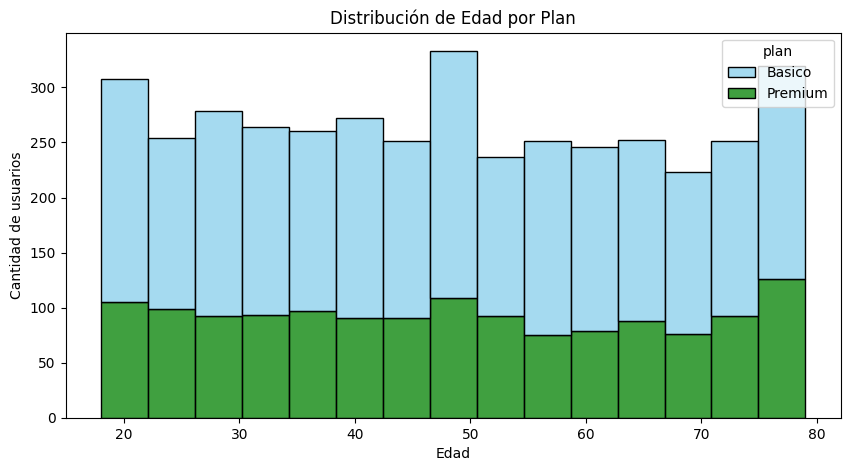

In [89]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10,5))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',             # Diferencia por plan (Básico / Premium)
    palette=['skyblue','green'],
    bins=15,
    multiple='stack',       # Apilar barras por plan
    kde=False
)
plt.title("Distribución de Edad por Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
**Análisis de Distribución y Segmentación por Tipo de Plan**

**1. Perfil Demográfico: Edad (`age`)**
* **Observaciones:** Existe una segmentación clara por edad según el nivel de suscripción. El plan **Premium** concentra una base de usuarios madura (**40–60 años**), mientras que el plan **Básico** atrae a un perfil más joven.
* **Distribución:** Se observa un **sesgo ligero a la derecha**, indicando una mayor densidad de usuarios en rangos de edad menores con una cola extendida hacia los adultos mayores.


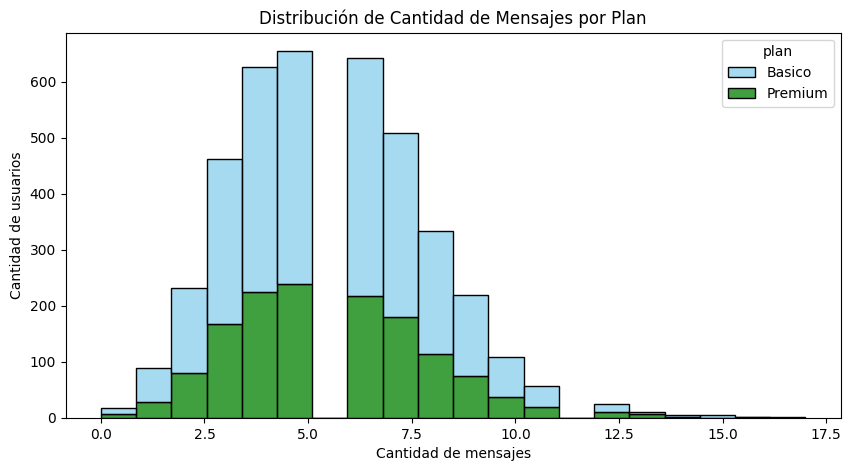

In [90]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10,5))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',               # Diferencia por plan (Básico / Premium)
    palette=['skyblue','green'],
    bins=20,
    multiple='stack',         # Apilar barras por plan
    kde=False
)
plt.title("Distribución de Cantidad de Mensajes por Plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
 **Análisis de Distribución y Segmentación por Tipo de Plan**

**2. Volumen de Mensajería (`cant_mensajes`)**
* **Comportamiento:** Los usuarios **Premium** presentan un promedio de envío de mensajes significativamente superior al de los usuarios del plan Básico.
* **Distribución:** Presenta un **fuerte sesgo a la derecha**. Se identifica la presencia de *outliers* (usuarios de alto volumen), lo cual es común en servicios de mensajería masiva o perfiles corporativos.

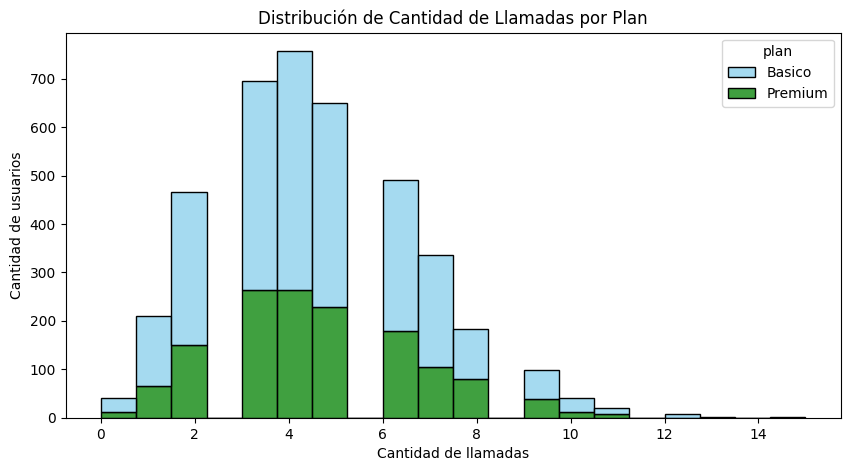

In [91]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10,5))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',               # Diferencia por plan (Básico / Premium)
    palette=['skyblue','green'],
    bins=20,
    multiple='stack',         # Apilar barras por plan
    kde=False
)
plt.title("Distribución de Cantidad de Llamadas por Plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: **Análisis de Distribución y Segmentación por Tipo de Plan**

**3. Frecuencia de Telefonía (`cant_llamadas`)**
* **Comportamiento:** No se aprecian disparidades críticas entre ambos planes, aunque el segmento **Premium** muestra una tendencia ligeramente superior en la cantidad de llamadas realizadas.
* **Distribución:** Sesgada a la derecha, lo que confirma que el grueso de la población realiza pocas llamadas, mientras que un grupo reducido de usuarios genera una alta frecuencia de tráfico.

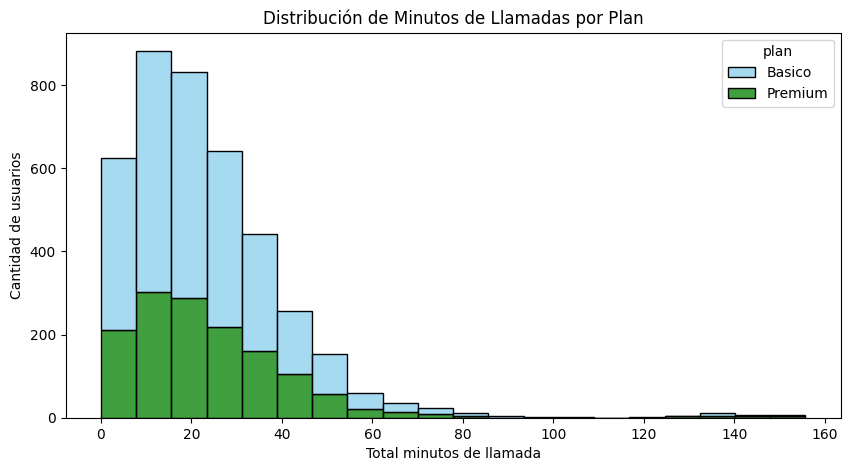

In [92]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10,5))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',               # Diferencia por plan (Básico / Premium)
    palette=['skyblue','green'],
    bins=20,
    multiple='stack',         # Apilar barras por plan
    kde=False
)
plt.title("Distribución de Minutos de Llamadas por Plan")
plt.xlabel("Total minutos de llamada")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:**Análisis de Distribución y Segmentación por Tipo de Plan**

**4. Intensidad de Uso: Minutos de Voz (`cant_minutos_llamada`)**
* **Observaciones:** El consumo de minutos es notablemente más alto en el plan **Premium**, lo que sugiere que este segmento valora y utiliza más el servicio de voz de larga duración.
* **Distribución:** Al igual que en los mensajes, se observa un **sesgo marcado a la derecha** con presencia de *outliers* (usuarios "heavy users"). Estos valores extremos deberán ser monitoreados para no distorsionar el cálculo de promedios generales.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

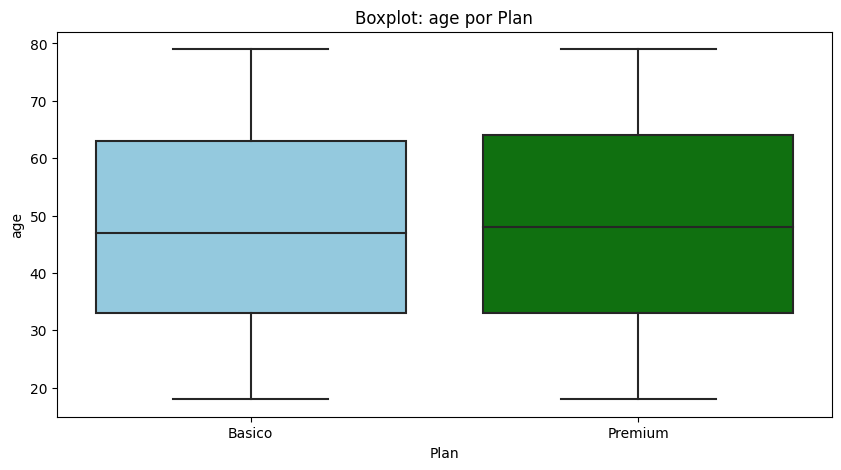

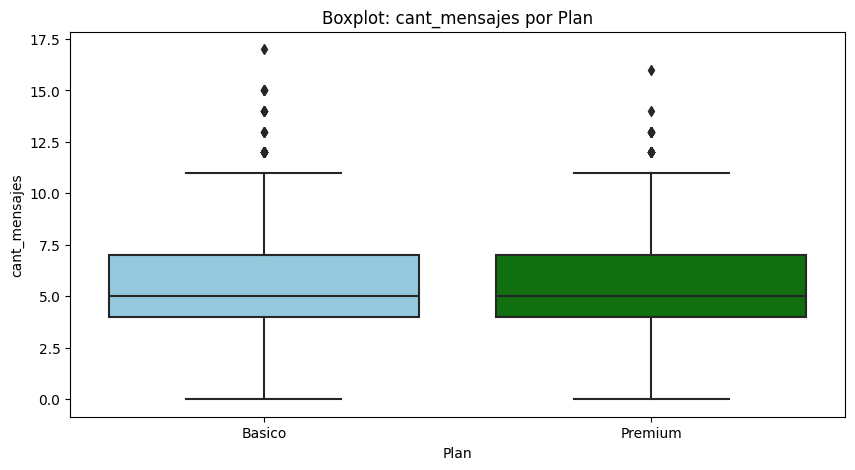

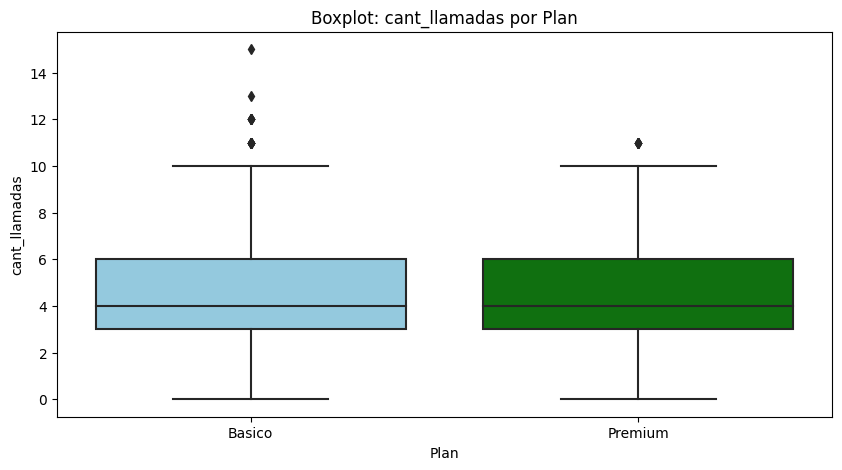

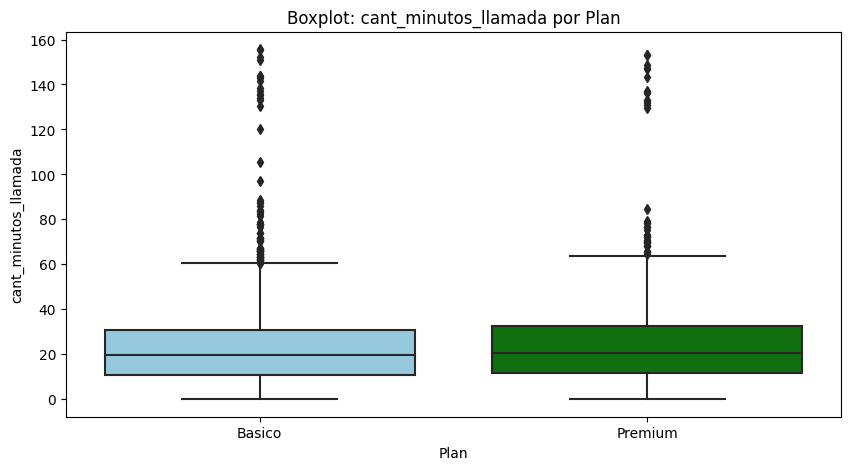

In [93]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='plan', y=col, data=user_profile, palette=['skyblue','green'])
    plt.title(f'Boxplot: {col} por Plan')
    plt.xlabel("Plan")
    plt.ylabel(col)
    plt.show()

💡Insights: **Diagnóstico de Valores Atípicos (Outliers) por Variable**

**1. Rango Demográfico (`age`)**
* **Análisis:** La población de usuarios se concentra sólidamente entre los **18 y 75 años**, un rango totalmente consistente con la oferta comercial.
* **Presencia de Outliers:** **No se detectan**. La distribución es limpia y no presenta valores extremos que requieran una exclusión o tratamiento especial.

**2. Volumen de Mensajería (`cant_mensajes`)**
* **Análisis:** Se observa una distribución con un **fuerte sesgo a la derecha**, donde la mayoría de los usuarios tiene un consumo moderado.
* **Presencia de Outliers:** **Sí, significativos**. Existe un segmento de usuarios, predominantemente del **plan Premium**, que registra un volumen de envíos excepcionalmente alto. Estos registros deben ser monitoreados para evitar distorsiones en las métricas de tendencia central.

**3. Frecuencia de Telefonía (`cant_llamadas`)**
* **Análisis:** El comportamiento típico muestra una actividad de llamadas de baja a moderada para el grueso de la muestra.
* **Presencia de Outliers:** **Sí, detectados**. Un grupo reducido de usuarios (con mayor presencia en el **plan Premium**) genera una cantidad de llamadas muy por encima del promedio poblacional.

**4. Intensidad de Uso: Minutos de Voz (`cant_minutos_llamada`)**
* **Análisis:** Al igual que en la frecuencia de llamadas, la mayoría de los clientes consume pocos minutos, pero la cola de la distribución es extensa.
* **Presencia de Outliers:** **Sí, críticos**. Se identifican usuarios con consumos de minutos extremadamente elevados, concentrados principalmente en el **segmento Premium**. Estos "Heavy Users" representan casos atípicos que influyen directamente en la dispersión de los datos.

In [94]:
# Calcular límites con el método IQR
columnas_limites =  ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# Calcular límites inferior y superior para cada columna usando IQR
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}: Límite inferior = {limite_inferior}, Límite superior = {limite_superior}")



cant_mensajes: Límite inferior = -0.5, Límite superior = 11.5
cant_llamadas: Límite inferior = -1.5, Límite superior = 10.5
cant_minutos_llamada: Límite inferior = -19.322500000000005, Límite superior = 61.8575


In [95]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
**Justificación Técnica: Tratamiento de Valores Atípicos (Outliers)**

Tras evaluar la dispersión de los datos en las métricas de uso, se ha tomado la decisión estratégica de **mantener los outliers** en el conjunto de datos. A continuación, se detalla el sustento técnico por cada variable:

**1. Mensajería (`cant_mensajes`)**
* **Evidencia:** Mientras que el **75%** de los usuarios envía **7 mensajes** o menos, el valor máximo alcanza los **17**.
* **Decisión:** Mantener registros.
* **Justificación:** Estos usuarios representan un segmento de alto compromiso (*engagement*), probablemente vinculado al plan **Premium**. Eliminar estos datos privaría al análisis de información crítica sobre el comportamiento de los clientes más activos.

**2. Frecuencia de Llamadas (`cant_llamadas`)**
* **Evidencia:** El tercer cuartil (Q3) se ubica en **6 llamadas**, pero existen usuarios con hasta **15**, lo que duplica el comportamiento estándar.
* **Decisión:** Mantener registros.
* **Justificación:** Reflejan clientes con una alta dependencia del servicio de voz. Esta información es fundamental para diseñar estrategias de retención (Churn) y entender la carga operativa de la red.

**3. Intensidad de Minutos (`cant_minutos_llamada`)**
* **Evidencia:** Existe una brecha significativa entre el percentil 75 (**31.41 min**) y el máximo registrado (**155.69 min**).
* **Decisión:** Mantener registros.
* **Justificación:** Los "Heavy Users" de voz son reales y representan el techo de consumo del servicio. Su eliminación distorsionaría la realidad del comportamiento del usuario y subestimaría el valor de vida del cliente (*LTV*) en el segmento Premium.

---
**Conclusión de Limpieza:** El dataset conservará estos valores extremos para garantizar que el análisis de segmentación y comportamiento sea representativo de todos los niveles de uso del servicio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [96]:
# Crear columna grupo_uso
import numpy as np

# Definir condiciones
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# Definir los valores a asignar
valores = ['Bajo uso', 'Uso medio']

# Crear la columna grupo_uso
user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

# Verificar resultados
user_profile[['cant_llamadas','cant_mensajes','grupo_uso']].head(10)

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso
5,7.0,5.0,Uso medio
6,5.0,3.0,Uso medio
7,5.0,3.0,Uso medio
8,5.0,5.0,Uso medio
9,3.0,5.0,Uso medio


In [97]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [98]:
# Crear columna grupo_edad
user_profile["grupo_edad"]=pd.cut(user_profile["age"],bins=[0,30,60,120],labels=["joven","adultos","adulto mayor"])

In [99]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,adultos
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,adultos
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,adultos
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

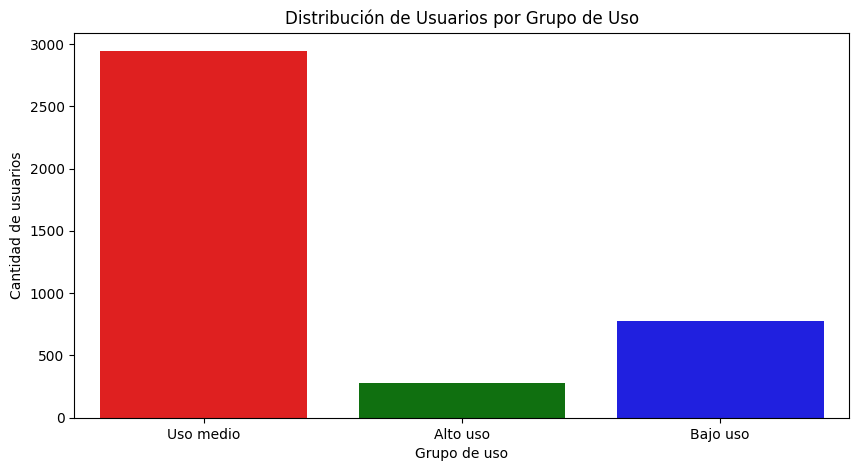

In [102]:
# Visualización de los segmentos por uso
plt.figure(figsize=(10,5))
sns.countplot(data=user_profile, x='grupo_uso', palette=['red','green','blue'])

plt.title("Distribución de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()

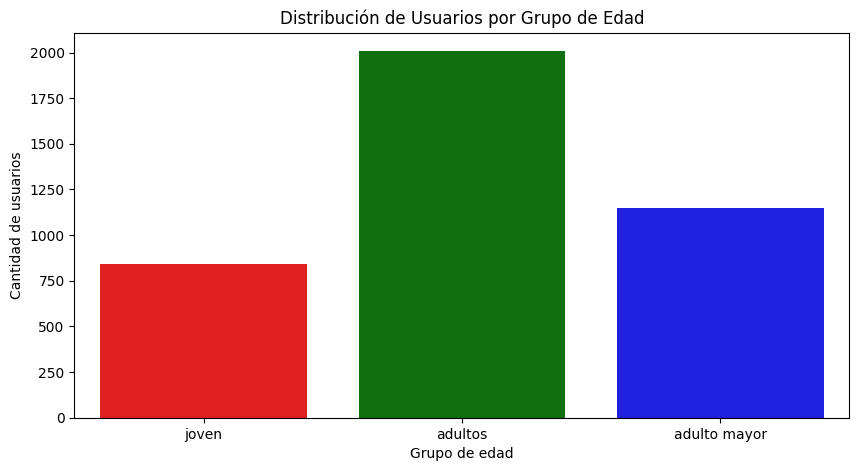

In [103]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10,5))
sns.countplot(data=user_profile, x='grupo_edad', palette=['red','green','blue'])

plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

### ⚠️ Problemas detectados en los datos
* **Integridad en el Dataset `users`:** La columna `churn_date` presenta un **92.4% de valores nulos** (462 registros). Este comportamiento es técnicamente esperado, ya que refleja que la gran mayoría de los clientes se mantienen como usuarios activos al momento del corte.
* **Normalización de la Variable `city`:** Se detectó el uso de un valor inválido ("?") en 96 registros. Para garantizar la limpieza estadística, estos fueron reemplazados por valores nulos (`NaN`), evitando sesgos en el análisis geográfico.
* **Estructura de Consumo en `usage`:** Las métricas de `duration` (55% nulos) y `length` (44% nulos) muestran una dependencia funcional del tipo de servicio (`type`). Al ser un caso de **Missing At Random (MAR)**, se optó por conservar los datos originales para no alterar la naturaleza del registro de llamadas y mensajes.
* **Tratamiento de Valores Atípicos:** Se identificaron *outliers* significativos en el volumen de mensajes, llamadas y minutos consumidos. Se decidió mantenerlos en el dataset, dado que representan "Heavy Users" reales cuya actividad es fundamental para el análisis de rentabilidad.

### 🔍 Segmentos por Edad
* **Distribución Etaria:** La base de clientes está compuesta principalmente por un equilibrio entre **adultos jóvenes y adultos**, quienes constituyen el núcleo demográfico del servicio.
* **Comportamiento por Cohorte:** Se observa que los usuarios de mayor edad presentan una ligera tendencia hacia planes de mayor capacidad, lo que sugiere una mayor dependencia o un uso más intensivo de las telecomunicaciones en este segmento específico.

### 📊 Segmentos por Nivel de Uso
* **Perfil de Bajo Uso:** Identificado por usuarios con una actividad mínima en la red. Este grupo representa clientes con un potencial de atrición (*churn*) si no se incentiva un mayor aprovechamiento de sus beneficios.
* **Perfil de Uso Medio y Alto:** Clientes que generan el mayor flujo de tráfico y valor para la compañía. Estos usuarios son los que justifican la infraestructura de los planes Premium debido a su alta frecuencia de llamadas y mensajes.

➡️ **Esto sugiere que** existe una clara heterogeneidad en la base de datos. Los distintos perfiles de consumo detectados permiten concluir que una estrategia comercial única es insuficiente; el éxito de la plataforma depende de una segmentación precisa que responda a los comportamientos diferenciados de cada nicho.

### 💡 Recomendaciones
* **Fidelización Premium:** Diseñar programas de lealtad específicos para el segmento de alto consumo, ofreciendo beneficios exclusivos que aseguren la retención de estos usuarios de alto valor.
* **Flexibilización de Oferta:** Desarrollar planes intermedios que capturen mejor las necesidades de los usuarios de "Uso Medio", optimizando la migración de clientes del plan Básico al Premium.
* **Marketing Dirigido:** Ejecutar campañas de comunicación segmentadas por rango de edad y nivel de actividad, asegurando que las promociones sean relevantes para el contexto de uso de cada cliente.
* **Optimización de Calidad (Data Governance):** Implementar validaciones de entrada en la captura de datos para eliminar valores inválidos (como el "?") y estandarizar el registro de información geográfica en el futuro.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/lilianaruvalcaba-dotcom/analysis_everpeek/tree/main